# Практическая работа №5. Метод главных компонент и визуальный анализ

**Содержание работы:**

1. **USArrests** — кластеризация (КА), снижение размерности методом **главных компонент (PCA)**,
   именование новых переменных и отображение наблюдений в координатах главных компонент с
   цветовой разметкой по кластерам.
2. **Данные по людям (лист «pop»)** — визуальный разведочный анализ и формулировка гипотез о
   том, какие переменные могут выступать **зависимыми** в регрессионной модели.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
RNG = 42
np.random.seed(RNG)
DATA = "../данные_весна_2026.xlsx"     # общий файл данных курса
print("Окружение готово")

Окружение готово


---
# Задача 1. USArrests: кластеры и главные компоненты

Набор `USArrests` (50 штатов США, 1973 г.): `Murder`, `Assault`, `Rape` — число
соответствующих преступлений на 100 тыс. населения, `UrbanPop` — доля городского населения (%).

In [2]:
usarrests_raw = '''Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9
Georgia,17.4,211,60,25.8
Hawaii,5.3,46,83,20.2
Idaho,2.6,120,54,14.2
Illinois,10.4,249,83,24.0
Indiana,7.2,113,65,21.0
Iowa,2.2,56,57,11.3
Kansas,6.0,115,66,18.0
Kentucky,9.7,109,52,16.3
Louisiana,15.4,249,66,22.2
Maine,2.1,83,51,7.8
Maryland,11.3,300,67,27.8
Massachusetts,4.4,149,85,16.3
Michigan,12.1,255,74,35.1
Minnesota,2.7,72,66,14.9
Mississippi,16.1,259,44,17.1
Missouri,9.0,178,70,28.2
Montana,6.0,109,53,16.4
Nebraska,4.3,102,62,16.5
Nevada,12.2,252,81,46.0
New Hampshire,2.1,57,56,9.5
New Jersey,7.4,159,89,18.8
New Mexico,11.4,285,70,32.1
New York,11.1,254,86,26.1
North Carolina,13.0,337,45,16.1
North Dakota,0.8,45,44,7.3
Ohio,7.3,120,75,21.4
Oklahoma,6.6,151,68,20.0
Oregon,4.9,159,67,29.3
Pennsylvania,6.3,106,72,14.9
Rhode Island,3.4,174,87,8.3
South Carolina,14.4,279,48,22.5
South Dakota,3.8,86,45,12.8
Tennessee,13.2,188,59,26.9
Texas,12.7,201,80,25.5
Utah,3.2,120,80,22.9
Vermont,2.2,48,32,11.2
Virginia,8.5,156,63,20.7
Washington,4.0,145,73,26.2
West Virginia,5.7,81,39,9.3
Wisconsin,2.6,53,66,10.8
Wyoming,6.8,161,60,15.6'''

usa = pd.DataFrame([r.split(',') for r in usarrests_raw.splitlines()],
                   columns=['State', 'Murder', 'Assault', 'UrbanPop', 'Rape']).set_index('State')
usa = usa.astype(float)
display(usa.head())
print("Размерность:", usa.shape)

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236.0,58.0,21.2
Alaska,10.0,263.0,48.0,44.5
Arizona,8.1,294.0,80.0,31.0
Arkansas,8.8,190.0,50.0,19.5
California,9.0,276.0,91.0,40.6


Размерность: (50, 4)


## 1a. Добавление столбца с номерами кластеров (по результатам КА)

Воспроизводим кластерный анализ из ПР-4: стандартизуем признаки и разбиваем штаты на
**4 кластера**. Используем оба подхода — иерархический (метод Варда) и *k*-средних — и
убеждаемся, что они согласованы; в таблицу добавляем итоговый столбец `cluster`.

In [3]:
usa_z = pd.DataFrame(StandardScaler().fit_transform(usa), columns=usa.columns, index=usa.index)

# Иерархическая кластеризация (Вард) -> 4 кластера
hc = fcluster(linkage(usa_z.values, method='ward'), 4, criterion='maxclust')
# k-средних -> 4 кластера
km = KMeans(n_clusters=4, n_init=50, random_state=RNG).fit(usa_z)

print(f"Согласованность иерархии и k-means (ARI): {adjusted_rand_score(hc, km.labels_):.3f}")

# В качестве итоговой разметки берём k-means; упорядочим номера кластеров по уровню
# преступности (среднему Murder), чтобы нумерация была интерпретируемой: 1 — самые спокойные.
order = (pd.Series(km.labels_, index=usa.index)
         .groupby(km.labels_).apply(lambda idx: usa.loc[idx.index, 'Murder'].mean()))
rank = order.rank().astype(int)                      # старый ярлык -> ранг 1..4
usa['cluster'] = [rank[l] for l in km.labels_]

print("\nРазмеры кластеров:")
print(usa['cluster'].value_counts().sort_index())
print("\nСредние показатели по кластерам:")
display(usa.groupby('cluster').mean().round(1))
display(usa.head(10))

Согласованность иерархии и k-means (ARI): 0.824

Размеры кластеров:
cluster
1    13
2    16
3    13
4     8
Name: count, dtype: int64

Средние показатели по кластерам:


,Murder,Assault,UrbanPop,Rape
cluster,,,,
1,3.6,78.5,52.1,12.2
2,5.7,138.9,73.9,18.8
3,10.8,257.4,76.0,33.2
4,13.9,243.6,53.8,21.4


,Murder,Assault,UrbanPop,Rape,cluster
State,,,,,
Alabama,13.2,236.0,58.0,21.2,4
Alaska,10.0,263.0,48.0,44.5,3
Arizona,8.1,294.0,80.0,31.0,3
Arkansas,8.8,190.0,50.0,19.5,4
California,9.0,276.0,91.0,40.6,3
Colorado,7.9,204.0,78.0,38.7,3
Connecticut,3.3,110.0,77.0,11.1,2
Delaware,5.9,238.0,72.0,15.8,2
Florida,15.4,335.0,80.0,31.9,3


В таблицу добавлен столбец **`cluster`** (1 — наиболее «спокойные» штаты … 4 — с наибольшим
уровнем насильственной преступности). Иерархия и *k*-средних дают близкие разбиения
(высокий ARI), поэтому разметку можно считать устойчивой.

## 1b. Снижение размерности методом главных компонент (PCA)

Метод главных компонент строит новые **некоррелированные** переменные (главные компоненты) —
линейные комбинации исходных признаков, упорядоченные по доле объяснённой дисперсии. PCA
выполняем на **стандартизованных** данных (признаки в разных единицах).

,Собств. значение,Доля дисперсии,Накопл. доля
Компонента,,,
PC1,2.531,0.620,0.620
PC2,1.010,0.247,0.868
PC3,0.364,0.089,0.957
PC4,0.177,0.043,1.000


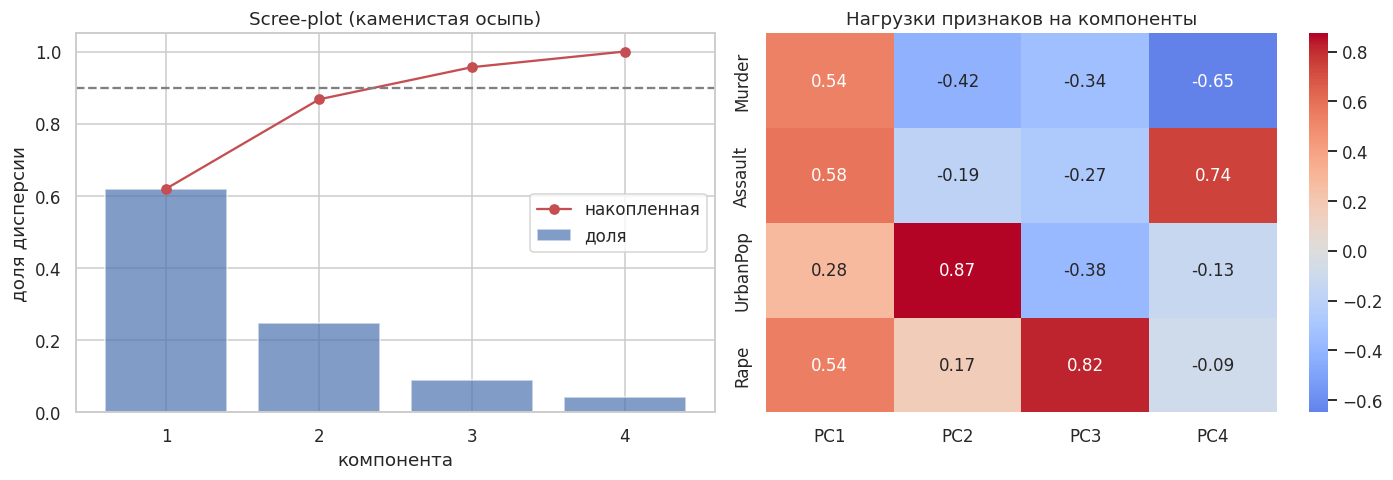

Матрица нагрузок:


,PC1,PC2,PC3,PC4
Murder,0.536,-0.418,-0.341,-0.649
Assault,0.583,-0.188,-0.268,0.743
UrbanPop,0.278,0.873,-0.378,-0.134
Rape,0.543,0.167,0.818,-0.089


In [4]:
features = ['Murder', 'Assault', 'UrbanPop', 'Rape']
pca = PCA(random_state=RNG).fit(usa_z[features])

evr = pca.explained_variance_ratio_
var_tbl = pd.DataFrame({
    'Компонента': [f'PC{i+1}' for i in range(4)],
    'Собств. значение': pca.explained_variance_,
    'Доля дисперсии': evr,
    'Накопл. доля': np.cumsum(evr)}).set_index('Компонента')
display(var_tbl.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(range(1, 5), evr, alpha=.7, label='доля')
ax[0].plot(range(1, 5), np.cumsum(evr), 'o-r', label='накопленная')
ax[0].axhline(0.9, ls='--', color='gray'); ax[0].set_xticks(range(1, 5))
ax[0].set_xlabel('компонента'); ax[0].set_ylabel('доля дисперсии')
ax[0].set_title('Scree-plot (каменистая осыпь)'); ax[0].legend()

# Нагрузки (loadings) = как исходные признаки проецируются на компоненты
loadings = pd.DataFrame(pca.components_.T, index=features,
                        columns=[f'PC{i+1}' for i in range(4)])
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax[1])
ax[1].set_title('Нагрузки признаков на компоненты')
plt.tight_layout(); plt.show()

print("Матрица нагрузок:")
display(loadings.round(3))

### Именование новых переменных

Смысл компонент читается по знаку и величине нагрузок:

- **PC1 — «Общий уровень преступности»** (≈62% дисперсии). Все три криминальных признака
  (`Murder`, `Assault`, `Rape`) входят с большими нагрузками одного знака, `UrbanPop` —
  слабее. Высокое значение PC1 ⇒ штат с высокой насильственной преступностью.
- **PC2 — «Урбанизация»** (≈25% дисперсии). Здесь доминирует `UrbanPop` (с одним знаком),
  тогда как `Murder` имеет противоположный знак. PC2 разделяет штаты «городские, но не
  обязательно криминальные» и «сельские с высоким уровнем убийств».

Две первые компоненты объясняют **≈87%** общей дисперсии — размерность снижена с 4 до 2
почти без потери информации.

In [5]:
# Знак PC1 делаем «больше = выше преступность» для интуитивной интерпретации
scores = pca.transform(usa_z[features])
if loadings.loc['Murder', 'PC1'] < 0:
    scores[:, 0] *= -1; loadings['PC1'] *= -1
if loadings.loc['UrbanPop', 'PC2'] < 0:
    scores[:, 1] *= -1; loadings['PC2'] *= -1

usa['PC1_преступность'] = scores[:, 0]
usa['PC2_урбанизация'] = scores[:, 1]
display(usa[['cluster', 'PC1_преступность', 'PC2_урбанизация']].head(8).round(2))

,cluster,PC1_преступность,PC2_урбанизация
State,,,
Alabama,4,0.99,-1.13
Alaska,3,1.95,-1.07
Arizona,3,1.76,0.75
Arkansas,4,-0.14,-1.12
California,3,2.52,1.54
Colorado,3,1.51,0.99
Connecticut,2,-1.36,1.09
Delaware,2,0.05,0.33


## 1c. Отображение наблюдений в координатах главных компонент

Каждый штат — точка в плоскости (PC1, PC2); цвет = номер кластера. Добавляем **biplot** —
стрелки исходных признаков, показывающие их вклад в компоненты.

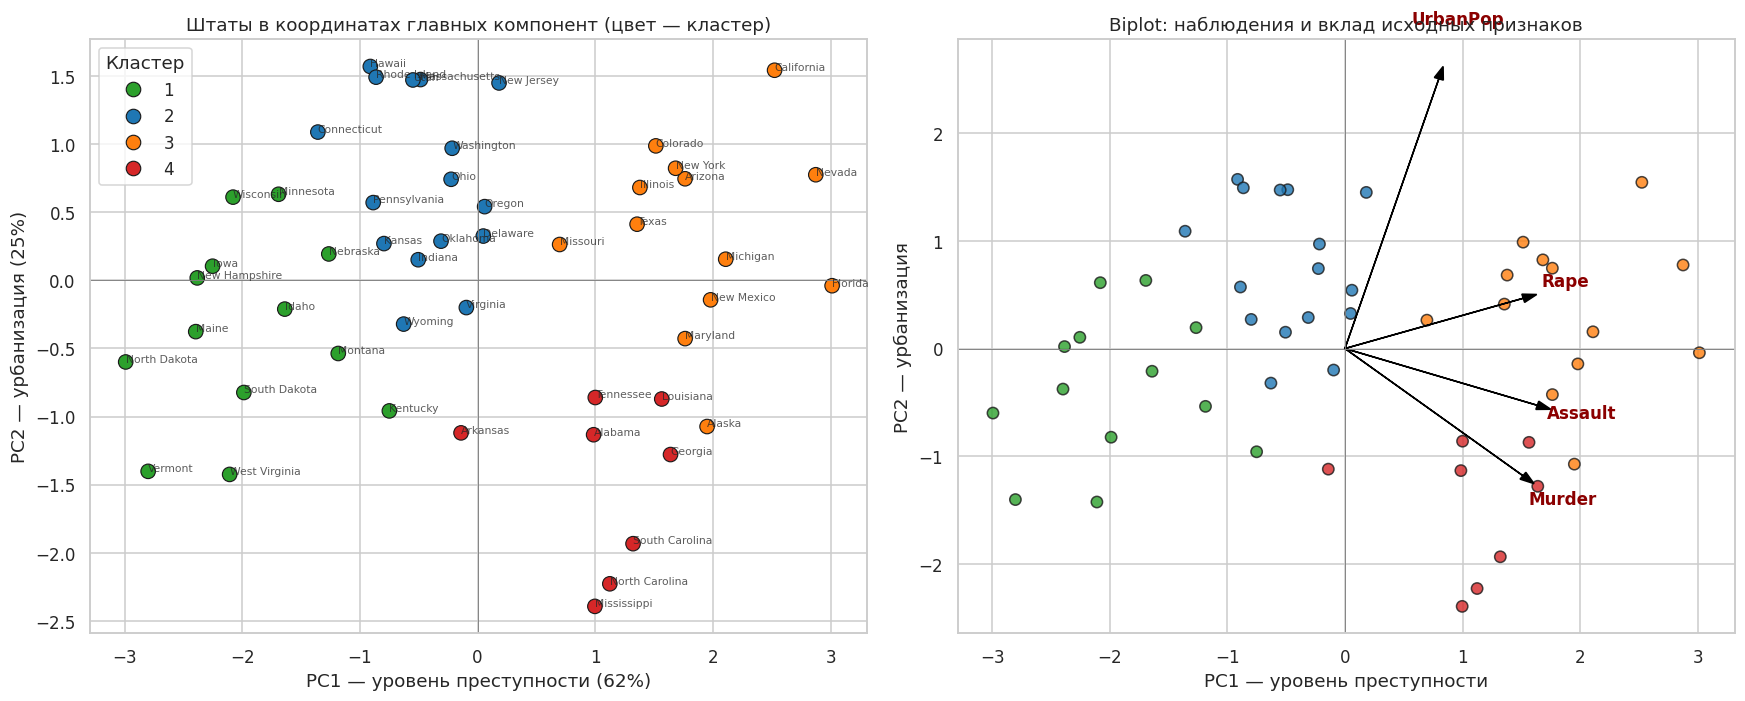

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))
palette = {1: '#2ca02c', 2: '#1f77b4', 3: '#ff7f0e', 4: '#d62728'}

# (1) Раскраска по кластерам + подписи штатов
sns.scatterplot(x=usa['PC1_преступность'], y=usa['PC2_урбанизация'],
                hue=usa['cluster'], palette=palette, s=90, ax=ax[0], edgecolor='k')
for st in usa.index:
    ax[0].annotate(st, (usa.loc[st, 'PC1_преступность'], usa.loc[st, 'PC2_урбанизация']),
                   fontsize=7, alpha=.75)
ax[0].axhline(0, color='gray', lw=.6); ax[0].axvline(0, color='gray', lw=.6)
ax[0].set_xlabel(f'PC1 — уровень преступности ({evr[0]:.0%})')
ax[0].set_ylabel(f'PC2 — урбанизация ({evr[1]:.0%})')
ax[0].set_title('Штаты в координатах главных компонент (цвет — кластер)')
ax[0].legend(title='Кластер')

# (2) Biplot: точки + стрелки признаков
ax[1].scatter(usa['PC1_преступность'], usa['PC2_урбанизация'],
              c=[palette[c] for c in usa['cluster']], s=55, edgecolor='k', alpha=.8)
scale = 3.0
for f in features:
    ax[1].arrow(0, 0, loadings.loc[f, 'PC1']*scale, loadings.loc[f, 'PC2']*scale,
                color='black', head_width=0.08, length_includes_head=True)
    ax[1].text(loadings.loc[f, 'PC1']*scale*1.15, loadings.loc[f, 'PC2']*scale*1.15,
               f, color='darkred', fontweight='bold', ha='center')
ax[1].axhline(0, color='gray', lw=.6); ax[1].axvline(0, color='gray', lw=.6)
ax[1].set_xlabel('PC1 — уровень преступности'); ax[1].set_ylabel('PC2 — урбанизация')
ax[1].set_title('Biplot: наблюдения и вклад исходных признаков')
plt.tight_layout(); plt.show()

**Выводы по задаче 1.**
- Метод главных компонент свёл 4 коррелированных признака к **2 интерпретируемым переменным**:
  *уровню преступности* (PC1) и *урбанизации* (PC2), сохранив ≈87% дисперсии.
- В плоскости (PC1, PC2) кластеры разделяются наглядно: слева (низкий PC1) — «спокойные»
  штаты, справа — криминальные; по вертикали штаты различаются степенью урбанизации.
- Biplot подтверждает именование: стрелки `Murder`/`Assault`/`Rape` направлены вдоль PC1,
  а `UrbanPop` — преимущественно вдоль PC2.

---
# Задача 2. Визуальный анализ данных по людям (лист «pop»)

Выборка: 32 человека — поровну Северная Европа (Скандинавия) и Южная (Средиземноморье),
поровну мужчин и женщин. Переменные:

| Переменная | Смысл |
|---|---|
| `Height` | рост, см |
| `Weight` | вес, кг |
| `Shoes` | размер обуви (EU) |
| `Strength` | индекс физической силы |
| `Age` | возраст, лет |
| `IQ` | коэффициент интеллекта |
| `Income` | доход, тыс. €/год |
| `Beer` | потребление пива, л/год |
| `Wine` | потребление вина, л/год |
| `Sex` | пол: 0 — муж., 1 — жен. |
| `Region` | регион: −1 — север, +1 — юг |

In [7]:
pop = pd.read_excel(DATA, sheet_name='pop', header=0)
num_cols = ['Height', 'Weight', 'Shoes', 'Strength', 'Age', 'IQ', 'Income', 'Beer', 'Wine']
pop = pop[['SR'] + num_cols + ['Sex', 'Region']].copy()
pop['Пол'] = pop['Sex'].map({0: 'муж', 1: 'жен'})
pop['Регион'] = pop['Region'].map({-1: 'Север', 1: 'Юг'})
print("Размерность:", pop.shape)
display(pop.describe().round(1))

Размерность: (32, 14)


,Height,Weight,Shoes,Strength,Age,IQ,Income,Beer,Wine,Sex,Region
count,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0
mean,173.1,64.5,39.9,81.5,34.4,115.1,27.4,249.5,131.6,0.5,0.0
std,10.1,15.2,3.9,7.3,9.5,12.2,8.9,90.6,49.5,0.5,1.0
min,157.0,46.0,34.0,70.0,18.0,96.0,11.0,116.0,45.0,0.0,-1.0
25%,164.8,50.0,36.0,75.0,26.8,105.0,19.8,181.2,90.8,0.0,-1.0
50%,173.5,64.5,40.0,81.0,34.0,114.0,30.0,252.5,126.5,0.5,0.0
75%,180.2,80.2,43.0,86.0,41.0,126.2,34.0,314.0,175.5,1.0,1.0
max,198.0,92.0,48.0,98.0,55.0,140.0,45.0,420.0,245.0,1.0,1.0


## Визуальный разведочный анализ

### 1. Корреляционная матрица
Начинаем с матрицы корреляций числовых переменных — она сразу показывает потенциальные
зависимости (кандидаты на связь «отклик ↔ предикторы»).

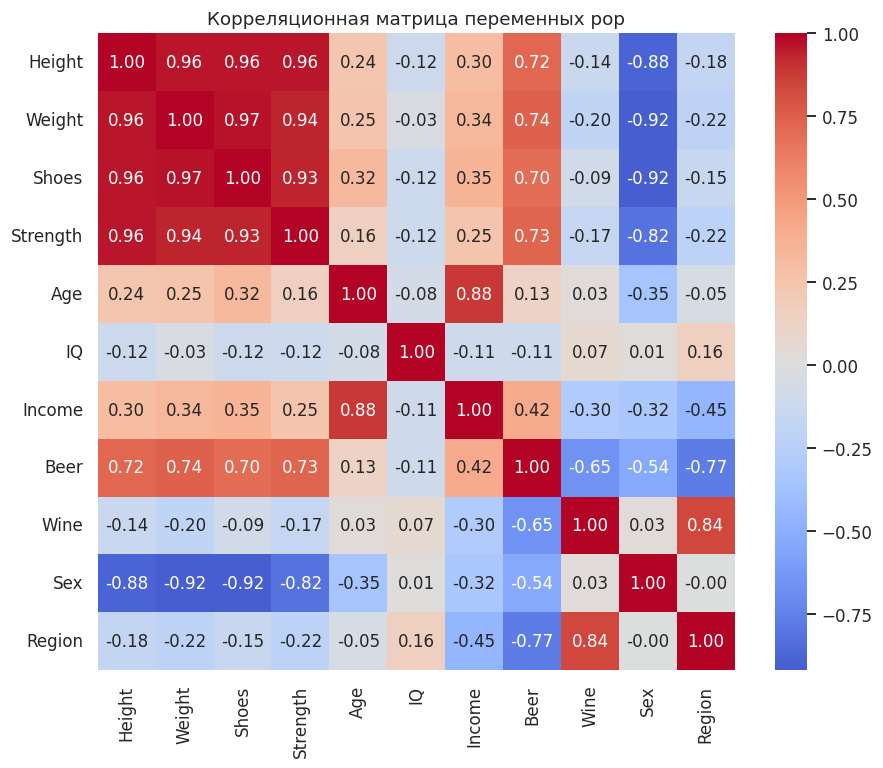

In [8]:
plt.figure(figsize=(8.5, 7))
corr = pop[num_cols + ['Sex', 'Region']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляционная матрица переменных pop')
plt.tight_layout(); plt.show()

### 2. Парные диаграммы (с разметкой по полу и региону)
Pairplot позволяет визуально оценить форму зависимостей и влияние группирующих факторов.

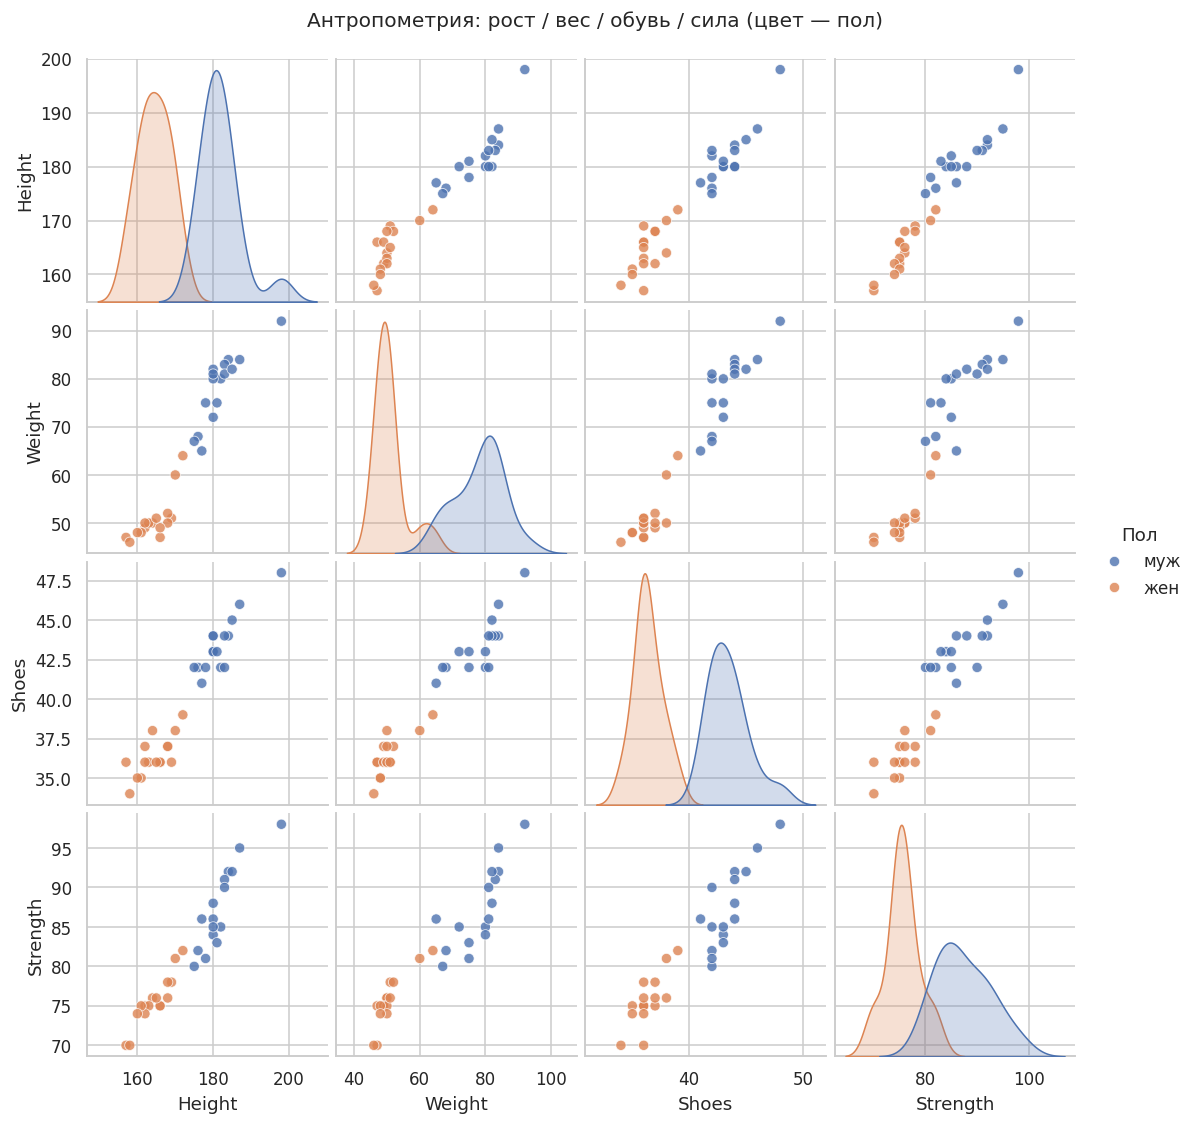

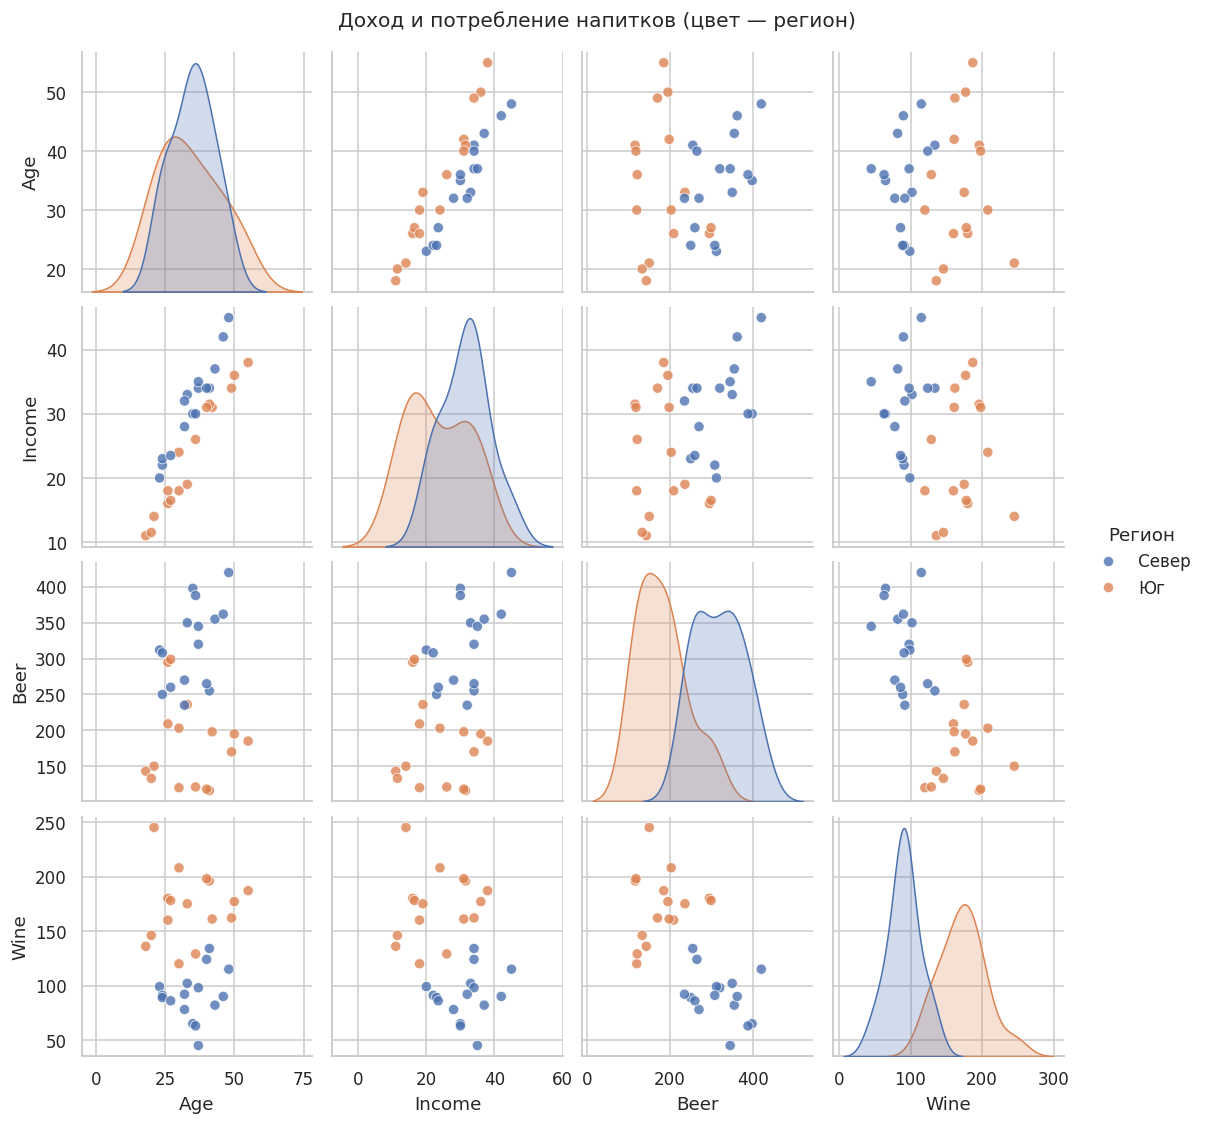

In [9]:
g = sns.pairplot(pop, vars=['Height', 'Weight', 'Shoes', 'Strength'],
                 hue='Пол', diag_kind='kde', plot_kws={'s': 45, 'alpha': .8})
g.fig.suptitle('Антропометрия: рост / вес / обувь / сила (цвет — пол)', y=1.02)
plt.show()

g2 = sns.pairplot(pop, vars=['Age', 'Income', 'Beer', 'Wine'],
                  hue='Регион', diag_kind='kde', plot_kws={'s': 45, 'alpha': .8})
g2.fig.suptitle('Доход и потребление напитков (цвет — регион)', y=1.02)
plt.show()

### 3. Группирующие факторы: распределения по полу и региону

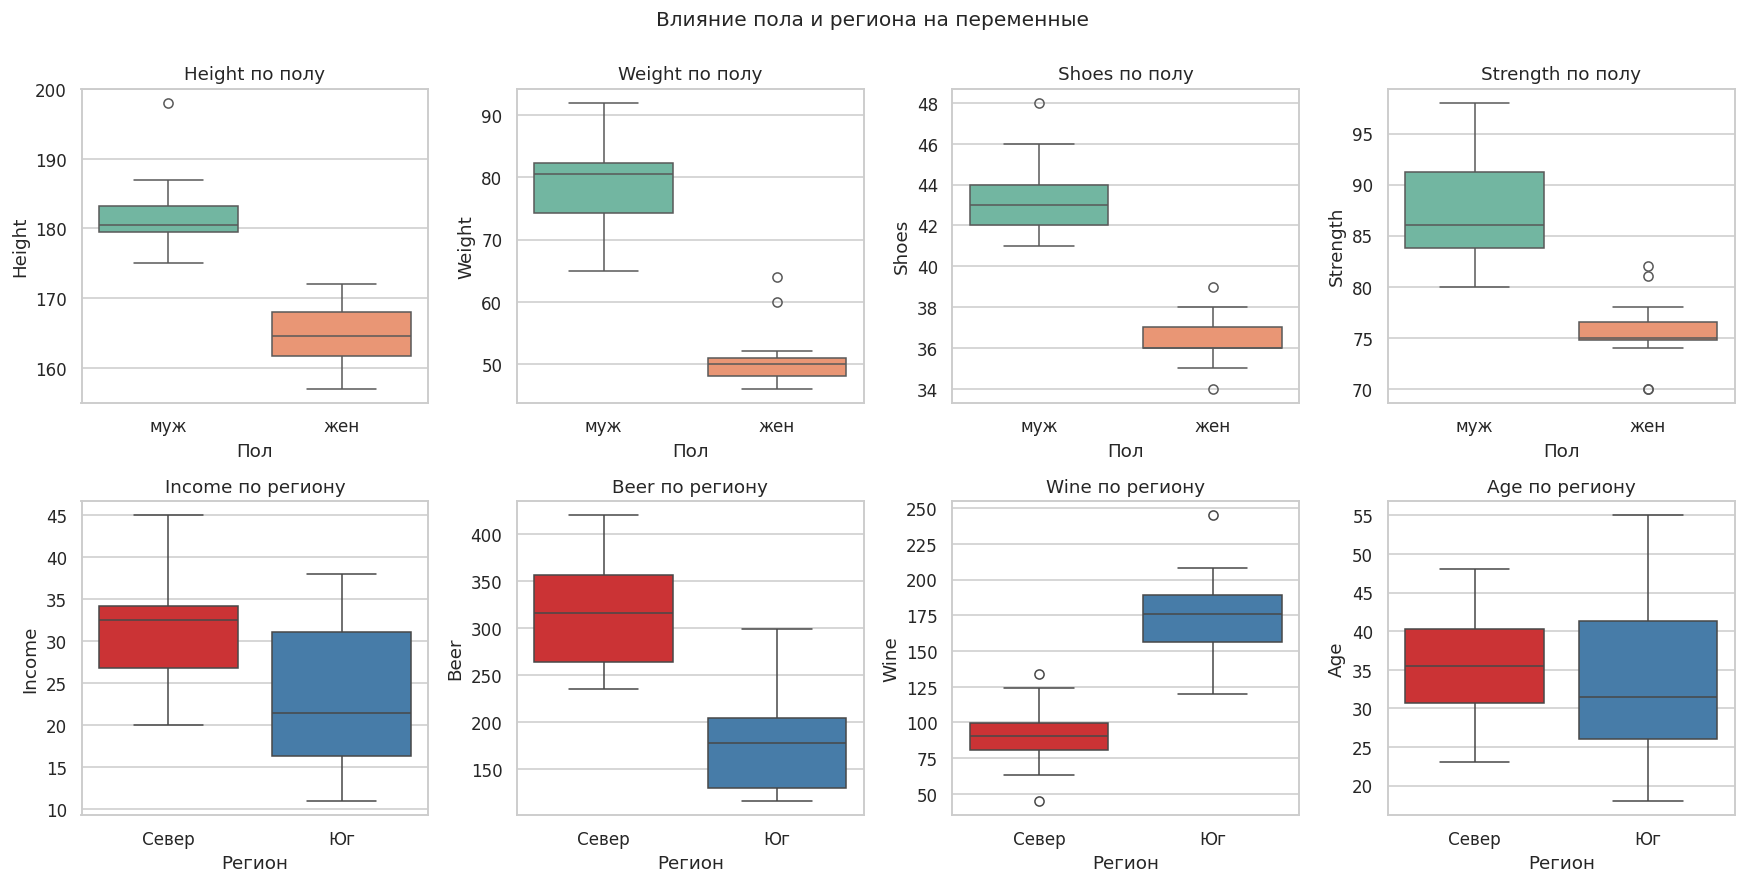

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes[0], ['Height', 'Weight', 'Shoes', 'Strength']):
    sns.boxplot(data=pop, x='Пол', y=col, hue='Пол', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{col} по полу')
for ax, col in zip(axes[1], ['Income', 'Beer', 'Wine', 'Age']):
    sns.boxplot(data=pop, x='Регион', y=col, hue='Регион', palette='Set1', legend=False, ax=ax)
    ax.set_title(f'{col} по региону')
plt.suptitle('Влияние пола и региона на переменные', y=1.0)
plt.tight_layout(); plt.show()

### 4. Ключевые зависимости крупным планом

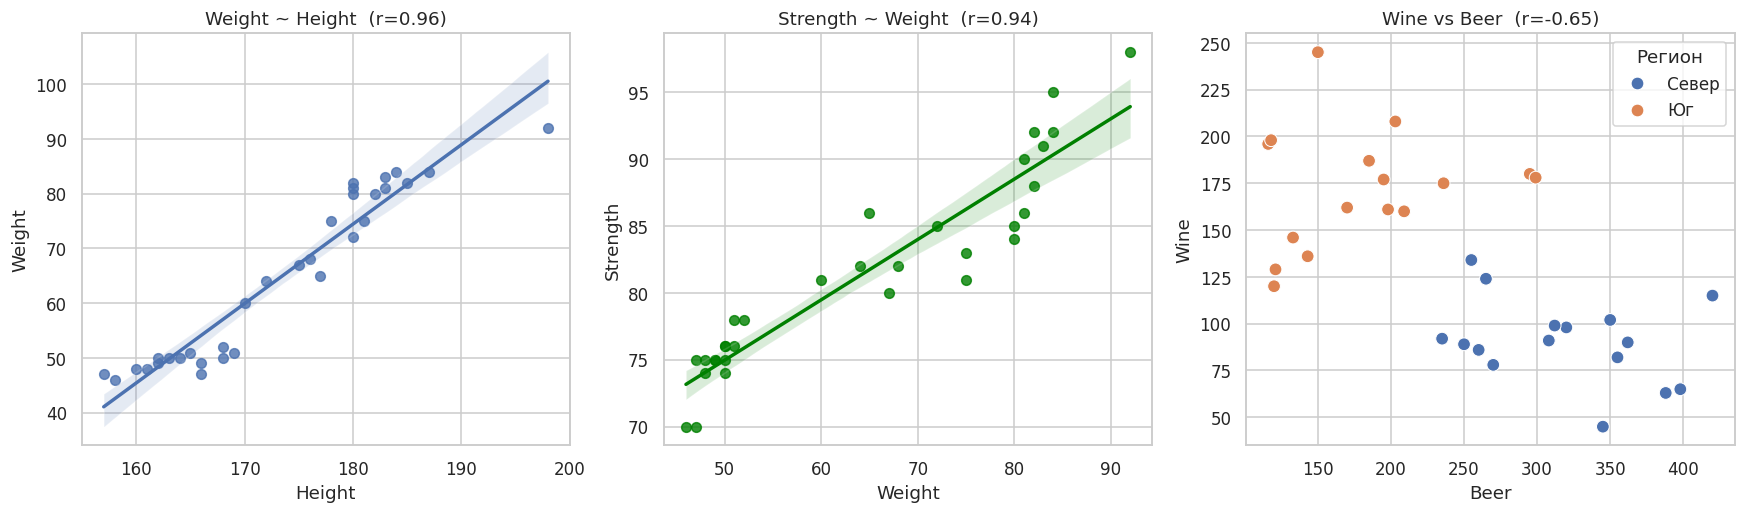

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
sns.regplot(data=pop, x='Height', y='Weight', ax=ax[0], scatter_kws={'s': 40})
ax[0].set_title(f"Weight ~ Height  (r={pop['Height'].corr(pop['Weight']):.2f})")

sns.regplot(data=pop, x='Weight', y='Strength', ax=ax[1], scatter_kws={'s': 40}, color='green')
ax[1].set_title(f"Strength ~ Weight  (r={pop['Weight'].corr(pop['Strength']):.2f})")

sns.scatterplot(data=pop, x='Beer', y='Wine', hue='Регион', s=70, ax=ax[2])
ax[2].set_title(f"Wine vs Beer  (r={pop['Beer'].corr(pop['Wine']):.2f})")
plt.tight_layout(); plt.show()

## 2a. Гипотезы о зависимых переменных в регрессионной модели

На основе визуального анализа и корреляций можно выделить несколько осмысленных
регрессионных моделей. **Зависимая (отклик)** — переменная, которую естественно объяснять
другими; **предикторы** — те, что с ней сильно связаны.

**Гипотеза 1. `Weight` (вес) — зависимая.**
$$\text{Weight} \sim \text{Height} + \text{Shoes} + \text{Sex}$$
Вес сильно положительно коррелирует с ростом и размером обуви (антропометрия) и заметно
различается по полу. Это самый сильный и физически обоснованный кандидат на отклик.

**Гипотеза 2. `Strength` (сила) — зависимая.**
$$\text{Strength} \sim \text{Weight} + \text{Height} + \text{Sex}$$
Индекс силы растёт с массой и ростом; у мужчин в среднем выше. Связь хорошо видна на
диаграмме рассеяния `Strength ~ Weight`.

**Гипотеза 3. `Shoes` (размер обуви) — зависимая.**
$$\text{Shoes} \sim \text{Height} + \text{Sex}$$
Размер обуви почти линейно связан с ростом; по сути дублирует антропометрический фактор.

**Гипотеза 4. Потребление напитков определяется регионом.**
$$\text{Wine} \sim \text{Region}, \qquad \text{Beer} \sim \text{Region}$$
По boxplot'ам юг (Средиземноморье) пьёт больше вина, север — больше пива; `Beer` и `Wine`
отрицательно коррелированы между собой. Region — сильный категориальный предиктор.

**Гипотеза 5. `Income` (доход) — зависимая.**
$$\text{Income} \sim \text{Age} + \text{Region}$$
Доход сильно растёт с возрастом ($r\approx0.88$) и различается по регионам (север богаче).

**Что в отклики НЕ годится.** `IQ` практически не коррелирует ни с одной переменной —
плохой кандидат и в отклики, и в предикторы. Технические признаки `Sex` и `Region` логичнее
использовать как **факторы-предикторы**, а не как отклик.

> **Итог.** Наиболее перспективная регрессионная модель — предсказание **веса** по росту,
> размеру обуви и полу (сильная, линейная, интерпретируемая связь). Вторые по силе —
> модели для **силы** и для **потребления вина/пива по региону**.